<a href="https://colab.research.google.com/github/biwwew/credit-card-fraud-detection/blob/main/biwash.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

         V1        V2        V3        V4        V5        V6        V7  \
0  1.699896 -6.927040 -1.995675  0.185324  0.520959  2.856266  2.193385   
1 -1.069413 -3.465743  0.144392  3.502545  0.954521  2.049907 -0.788140   
2 -1.139802  0.085168 -2.346645  1.048328  0.264780  2.338693  0.399271   
3 -1.019115 -1.862544 -1.651641 -1.886920  0.108876 -1.674420 -0.933760   
4 -0.237129  3.558836  2.018971  0.007138  0.556833 -0.612601 -1.685003   

         V8        V9       V10  ...       V22       V23       V24       V25  \
0  0.509758  1.540113  5.295314  ... -3.091310  2.251862  0.454669  0.960095   
1 -0.303263 -1.197029 -3.323306  ...  1.242258  1.725149 -1.780458 -0.220155   
2 -0.138916 -1.308191 -2.546482  ...  1.051508  0.081351  3.888520  0.177315   
3  1.321304  3.534666  0.024595  ... -3.600047  0.247401  1.155921 -0.655186   
4 -0.938191 -5.107793 -0.929620  ... -2.315168  0.219238 -4.324023 -0.193312   

        V26       V27       V28      Time  Amount  Class  
0  0.6349

/tmp/ipykernel_1221/2725247614.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Class", palette=["#4CAF50", "#F44336"])


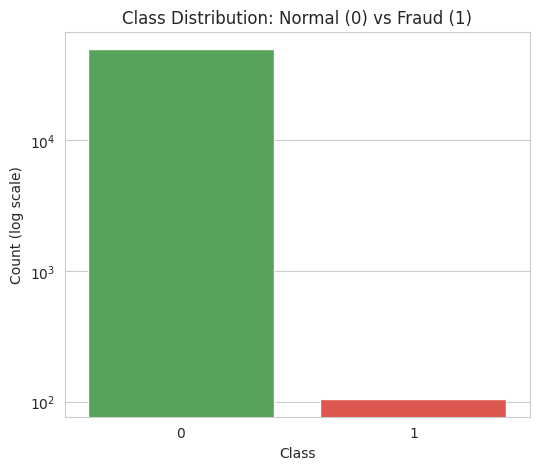

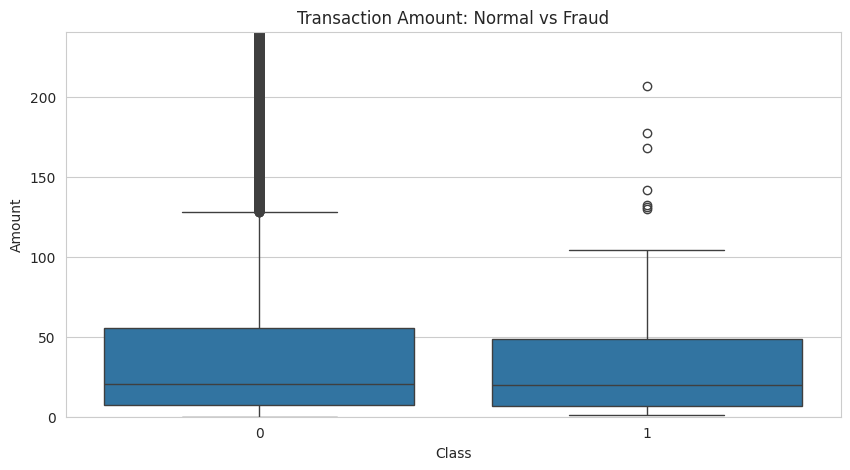

         count       mean         std   min   25%    50%     75%      max
Class                                                                    
0      49895.0  61.805963  159.463453  0.02  7.39  20.33  55.755  6277.16
1        105.0  56.629143  116.063142  0.95  6.46  20.04  48.910   839.16


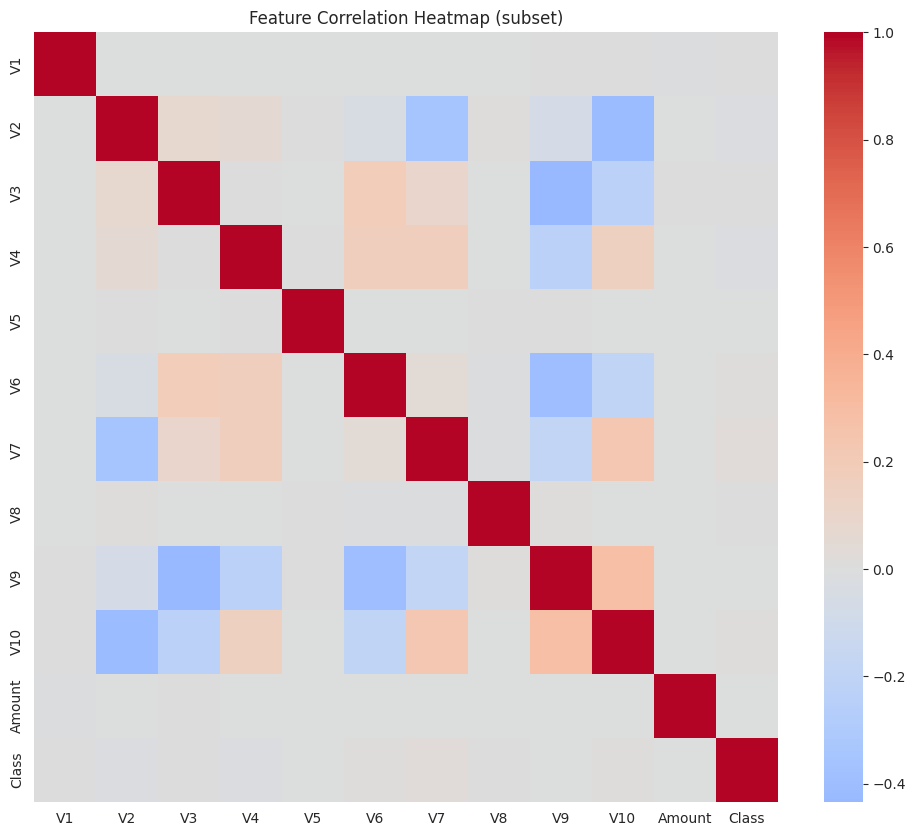

Training set: 37500 transactions, 79 fraud (0.211%)
Test set: 12500 transactions, 26 fraud (0.208%)
Before SMOTE: {0: 37421, 1: 79}
After SMOTE: {0: 37421, 1: 37421}

Logistic Regression
              precision    recall  f1-score   support

      Normal       1.00      0.91      0.95     12474
       Fraud       0.02      0.69      0.03        26

    accuracy                           0.91     12500
   macro avg       0.51      0.80      0.49     12500
weighted avg       1.00      0.91      0.95     12500


Decision Tree
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98     12474
       Fraud       0.01      0.19      0.02        26

    accuracy                           0.96     12500
   macro avg       0.50      0.58      0.50     12500
weighted avg       1.00      0.96      0.98     12500


Random Forest
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     12474
       Fraud       0

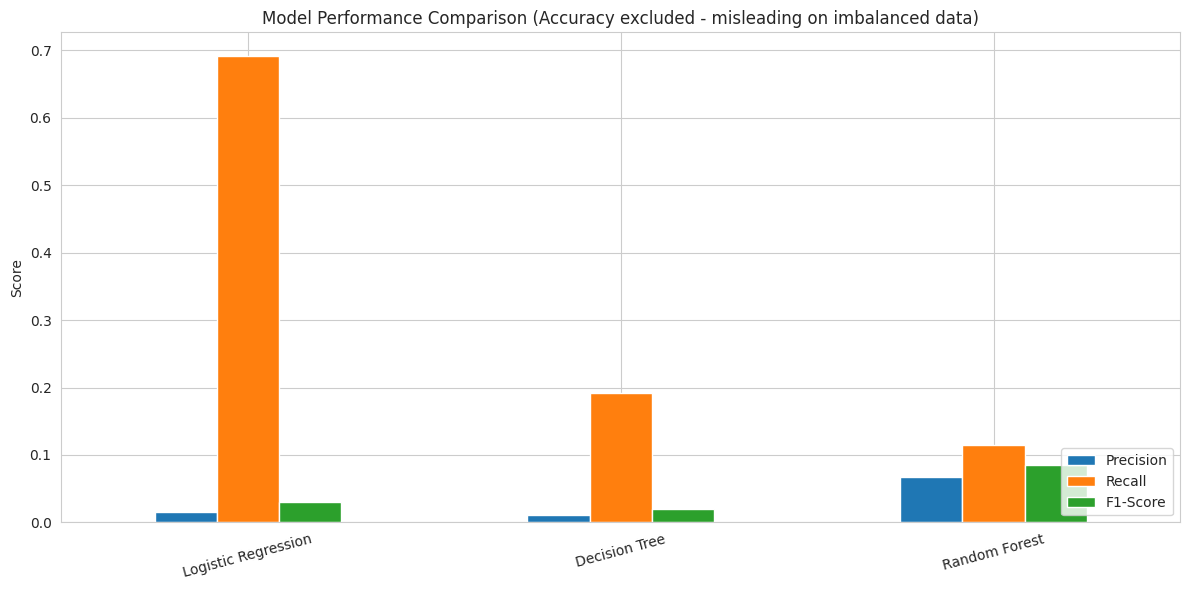


Best performing model (by F1-Score): Random Forest


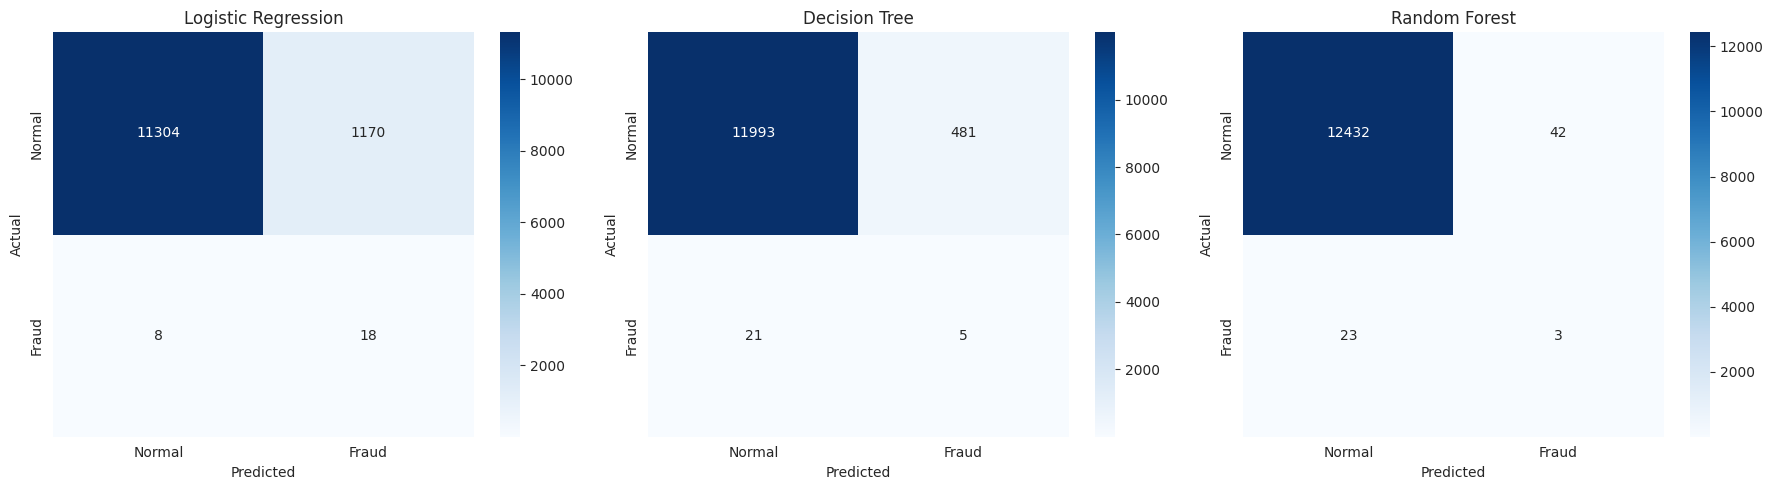

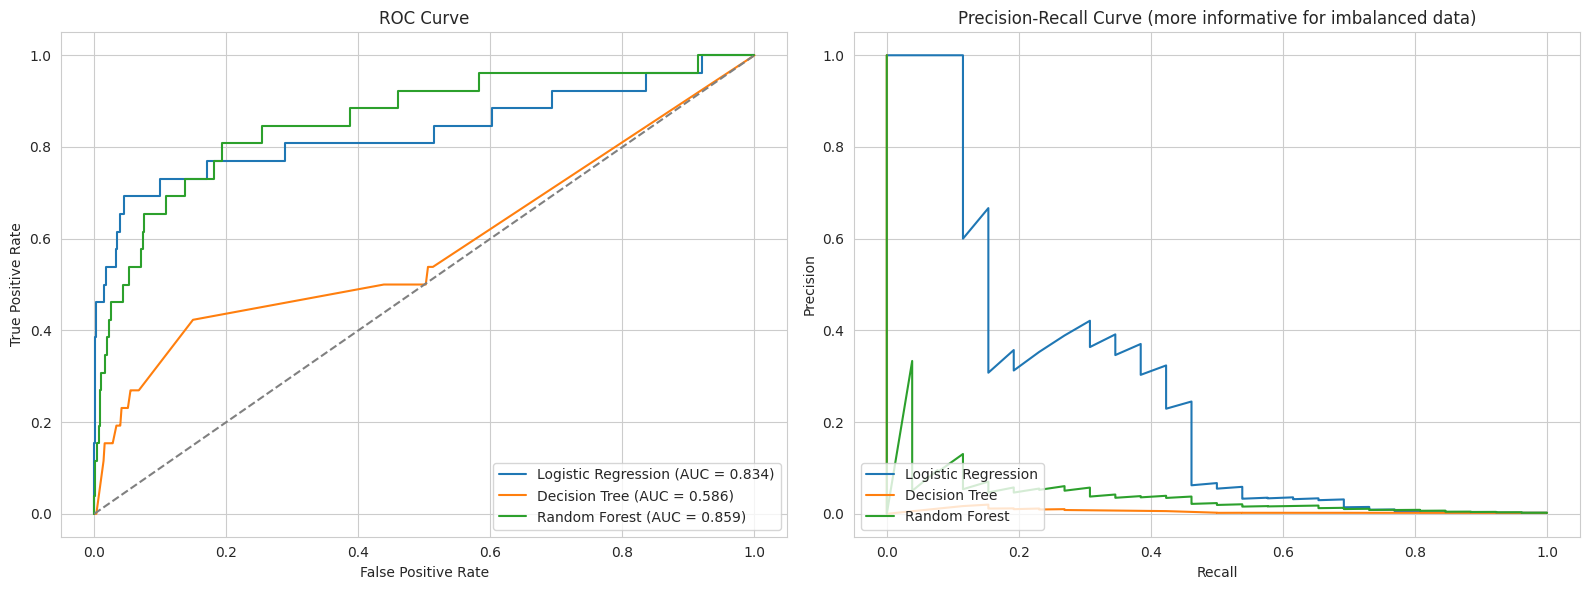

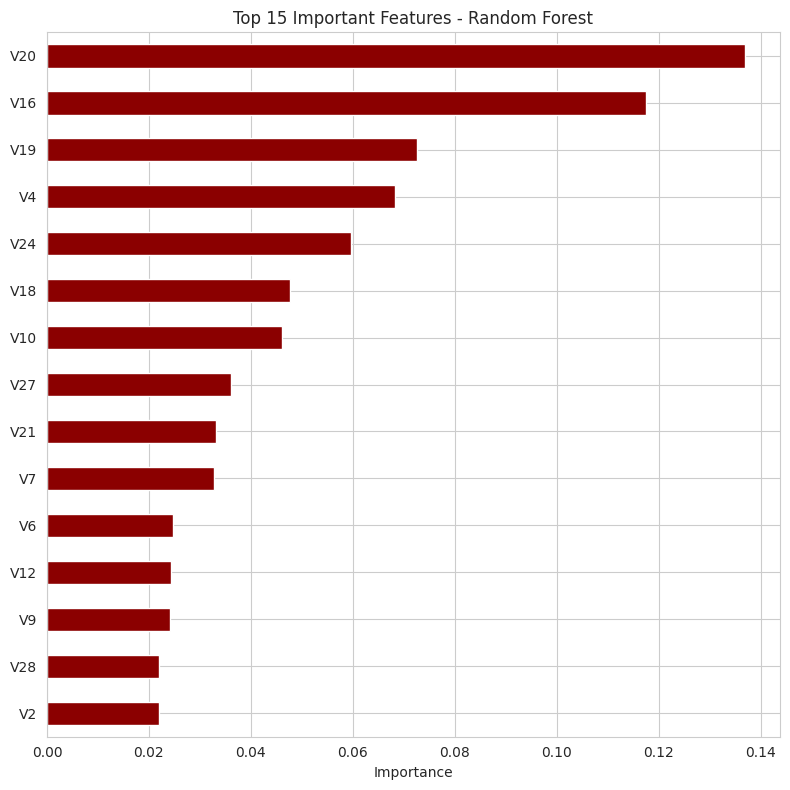

Threshold tuning for Random Forest:

Threshold 0.3 -> Precision: 0.040, Recall: 0.346, F1: 0.071
Threshold 0.4 -> Precision: 0.051, Recall: 0.192, F1: 0.081
Threshold 0.5 -> Precision: 0.067, Recall: 0.115, F1: 0.085
Threshold 0.6 -> Precision: 0.067, Recall: 0.038, F1: 0.049
Threshold 0.7 -> Precision: 0.333, Recall: 0.038, F1: 0.069
Model, scaler, and results saved successfully.

===== PROJECT SUMMARY =====
Dataset: 50000 transactions (105 fraud, 0.210% fraud rate)
Technique for imbalance: SMOTE oversampling on training data
Best Model: Random Forest
Precision : 0.0667
Recall    : 0.1154
F1-Score  : 0.0845
PR-AUC    : 0.0452


In [1]:
# ==========================================================================
# CREDIT CARD FRAUD DETECTION USING MACHINE LEARNING
# YBI Foundation - Machine Learning with Python Course Project
# ==========================================================================
# Run this in Google Colab. Copy each section (marked with # %%) into a
# separate cell, or just run the whole script as one cell.
#
# NOTE ON DATASET:
# The real-world dataset for this problem is the Kaggle "Credit Card Fraud
# Detection" dataset (284,807 transactions, PCA-anonymized features V1-V28,
# ~0.17% fraud rate). It's too large to auto-download here, so Section 2
# lets you EITHER upload the real Kaggle CSV OR auto-generate a synthetic
# dataset with the same structure and imbalance so the project still runs
# end-to-end without it. See Section 2 for instructions.
# ==========================================================================

# %% [1] IMPORT LIBRARIES
!pip install imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, auc, precision_recall_curve,
                              average_precision_score)
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
np.random.seed(42)

# %% [2] LOAD DATASET
# OPTION A (recommended if you have it): download creditcard.csv from
# https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud, then in Colab run:
#
#   from google.colab import files
#   uploaded = files.upload()
#   df = pd.read_csv("creditcard.csv")
#
# OPTION B (default here): auto-generate a synthetic dataset with the same
# structure - 28 anonymized PCA-style features (V1-V28), Time, Amount, and
# a heavily imbalanced Class label (0 = normal, 1 = fraud).

from sklearn.datasets import make_classification

n_samples = 50000
n_features = 28

X_synthetic, y_synthetic = make_classification(
    n_samples=n_samples,
    n_features=n_features,
    n_informative=15,
    n_redundant=5,
    n_clusters_per_class=2,
    weights=[0.9983, 0.0017],   # mimics real ~0.17% fraud rate
    flip_y=0.001,
    class_sep=1.2,
    random_state=42
)

df = pd.DataFrame(X_synthetic, columns=[f"V{i+1}" for i in range(n_features)])
df["Time"] = np.sort(np.random.uniform(0, 172800, n_samples))  # 2 days in seconds
df["Amount"] = np.round(np.random.lognormal(mean=3, sigma=1.5, size=n_samples), 2)
df["Class"] = y_synthetic

print(df.head())
print(df.shape)

# %% [3] EXPLORATORY DATA ANALYSIS (EDA)
print(df.isnull().sum().sum(), "missing values")
print(df["Class"].value_counts())

fraud_pct = df["Class"].value_counts(normalize=True)[1] * 100
print(f"Fraudulent transactions: {fraud_pct:.3f}% of all transactions")

plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="Class", palette=["#4CAF50", "#F44336"])
plt.title("Class Distribution: Normal (0) vs Fraud (1)")
plt.yscale("log")
plt.ylabel("Count (log scale)")
plt.show()

# Transaction amount distribution: fraud vs normal
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Class", y="Amount")
plt.title("Transaction Amount: Normal vs Fraud")
plt.ylim(0, df["Amount"].quantile(0.95))
plt.show()

print(df.groupby("Class")["Amount"].describe())

# Correlation heatmap (subset of features for readability)
plt.figure(figsize=(12, 10))
corr = df[[f"V{i}" for i in range(1, 11)] + ["Amount", "Class"]].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Feature Correlation Heatmap (subset)")
plt.show()

# %% [4] FEATURE SCALING
# Time and Amount are on very different scales than the PCA features, so
# they need scaling before modeling.
scaler = StandardScaler()
df["Time_scaled"] = scaler.fit_transform(df[["Time"]])
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])
df.drop(["Time", "Amount"], axis=1, inplace=True)

# %% [5] TRAIN-TEST SPLIT (stratified, since data is imbalanced)
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} transactions, "
      f"{y_train.sum()} fraud ({y_train.mean()*100:.3f}%)")
print(f"Test set: {X_test.shape[0]} transactions, "
      f"{y_test.sum()} fraud ({y_test.mean()*100:.3f}%)")

# %% [6] HANDLE CLASS IMBALANCE WITH SMOTE
# SMOTE creates synthetic minority-class (fraud) samples in the training
# set ONLY, so the test set stays realistic for honest evaluation.
print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("After SMOTE:", y_train_balanced.value_counts().to_dict())

# %% [7] TRAIN MULTIPLE MODELS
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=12,
                                             random_state=42, n_jobs=-1)
}

results = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    ap = average_precision_score(y_test, y_prob)

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec,
                      "F1-Score": f1, "Avg Precision (PR-AUC)": ap}
    predictions[name] = y_pred
    probabilities[name] = y_prob

    print(f"\n{'='*55}\n{name}\n{'='*55}")
    print(classification_report(y_test, y_pred, target_names=["Normal", "Fraud"]))

# %% [8] COMPARE MODEL PERFORMANCE
# IMPORTANT: accuracy is misleading here (predicting "no fraud" for
# everything already gives ~99.8% accuracy). Precision, Recall, F1, and
# PR-AUC are the metrics that actually matter for fraud detection.
results_df = pd.DataFrame(results).T
print("\nModel Comparison:\n", results_df)

results_df[["Precision", "Recall", "F1-Score"]].plot(kind="bar", figsize=(12, 6))
plt.title("Model Performance Comparison (Accuracy excluded - misleading on imbalanced data)")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

best_model_name = results_df["F1-Score"].idxmax()
print(f"\nBest performing model (by F1-Score): {best_model_name}")

# %% [9] CONFUSION MATRICES
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Fraud"], yticklabels=["Normal", "Fraud"],
                ax=axes[idx])
    axes[idx].set_title(name)
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# %% [10] ROC CURVES AND PRECISION-RECALL CURVES
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, y_prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

    prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob)
    axes[1].plot(rec_curve, prec_curve, label=name)

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

axes[1].set_title("Precision-Recall Curve (more informative for imbalanced data)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

# %% [11] FEATURE IMPORTANCE (best tree-based model)
if best_model_name in ["Random Forest", "Decision Tree"]:
    best_model = models[best_model_name]
    importance = pd.Series(best_model.feature_importances_, index=X.columns)
    importance = importance.sort_values(ascending=False).head(15)

    plt.figure(figsize=(8, 8))
    importance.sort_values().plot(kind="barh", color="darkred")
    plt.title(f"Top 15 Important Features - {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

# %% [12] THRESHOLD TUNING
# By default, models classify at a 0.5 probability threshold. In fraud
# detection you often want to catch more fraud even at the cost of more
# false alarms (or vice versa) - this shows how adjusting the threshold
# changes precision/recall trade-off.
best_model = models[best_model_name]
y_prob_best = probabilities[best_model_name]

thresholds_to_try = [0.3, 0.4, 0.5, 0.6, 0.7]
print(f"Threshold tuning for {best_model_name}:\n")
for t in thresholds_to_try:
    y_pred_t = (y_prob_best >= t).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    print(f"Threshold {t:.1f} -> Precision: {p:.3f}, Recall: {r:.3f}, F1: {f:.3f}")

# %% [13] SAVE MODEL
import joblib

joblib.dump(best_model, "fraud_detection_model.pkl")
joblib.dump(scaler, "scaler.pkl")
results_df.to_csv("model_comparison_results.csv")

print("Model, scaler, and results saved successfully.")

# %% [14] CONCLUSION (print summary for report)
print("\n===== PROJECT SUMMARY =====")
print(f"Dataset: {len(df)} transactions ({int(y.sum())} fraud, {fraud_pct:.3f}% fraud rate)")
print(f"Technique for imbalance: SMOTE oversampling on training data")
print(f"Best Model: {best_model_name}")
print(f"Precision : {results_df.loc[best_model_name, 'Precision']:.4f}")
print(f"Recall    : {results_df.loc[best_model_name, 'Recall']:.4f}")
print(f"F1-Score  : {results_df.loc[best_model_name, 'F1-Score']:.4f}")
print(f"PR-AUC    : {results_df.loc[best_model_name, 'Avg Precision (PR-AUC)']:.4f}")